In [1]:
import stan
import pandas as pd
import numpy as np
import scipy.stats as stats 
import matplotlib
import matplotlib.pyplot as plt
import arviz as az
#matplotlib.rcParams['figure.figsize']=5,5
matplotlib.rcParams['figure.dpi']=100
#plt.style.use('ggplot')

# this is a work around found at 
# https://stackoverflow.com/questions/56154176/runtimeerror-asyncio-run-cannot-be-called-from-a-running-event-loop-in-spyd
import nest_asyncio
nest_asyncio.apply()

/home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Gaia measures distance to stars through paralax.  It measures the distance to a given star $n$ times and then reports: the mean ($\mu_{rep}$) and  standard deviation ($\sigma_{rep}$) for the distance, and how many times it measured it ($n$).  However, sometimes because of the uncertainty in the measurements the reported mean distance is negative, $\mu_{rep} < 0$ !!  Of course that this is not physical.  However, could we make a model to infer a probability distribution for the true $\mu_{true}$ and $\sigma_{true}$ ?

In [2]:
my_model = """
data {
 int <lower=0> N; // number of datapoints
 real mu_rep, sigma_rep;  // the reported mu and sigma
}

parameters {
  vector [N] x; // the N measurements which we ignore
  real<lower=0> mu_true;  // the true mu and sigma
  real<lower=0> sigma_true;
}

transformed parameters{
  // We need this block to give the program a deterministic equation between the variables.
  real mu_temp=0, sigma_temp=0;

  // This is how the mu and sigma are supposed to be computed from the ignored x[n]
  mu_temp = sum(x[1:N]) / N;  
  sigma_temp = sum(abs(x - mu_rep)) / N;  // STAN supports vectorized expressions as this, where mu is an scalar
    
  mu_temp = mu_rep;
  sigma_temp = sigma_rep;
}

model {
    mu_true ~ normal(0,5);
    sigma_true ~ normal(0,2*sigma_rep);
    x ~ normal(mu_true, sigma_true);  // STAN supports vectorized expressions as this
    }
"""

In [3]:
my_data = {'N': 5, 'mu_rep': -1, 'sigma_rep': 8}

In [4]:
model = stan.build(my_model, data=my_data, random_seed=0)

Building...

In Datei, eingebunden von /home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 von /home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 von /home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 von /home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/stan/math/rev.hpp:10,
                 von /home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/stan/math.hpp:19,
                 von /home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 von /home/grimm/.cache/httpstan/4.13.0/models/cbxstcjl/model_cbxstcjl.cpp:2:
/home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In


Building: 16.2s, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.


In [5]:
fit = model.sample(num_chains=4, num_samples=1000, num_warmup=3000, delta=0.95)

Sampling:   0%
Sampling:  25% (4000/16000)
Sampling:  50% (8000/16000)
Sampling:  75% (12000/16000)
Sampling: 100% (16000/16000)
Sampling: 100% (16000/16000), done.
Messages received during sampling:
  Gradient evaluation took 2.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.29 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.29 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 3.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.32 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.3 seconds.
  Adjust your expectations accordingly!


In [6]:
df = fit.to_frame() 
df

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,x.1,x.2,x.3,x.4,x.5,mu_true,sigma_true,mu_temp,sigma_temp
draws,,,,,,,,,,,,,,,,
0,-8.783473,0.995602,0.129730,4.0,15.0,0.0,10.034426,-2.387167,-2.938662,-6.761554,1.649923,-1.405736,1.786704,7.634553,-1.0,8.0
1,-9.675017,0.996088,0.053170,5.0,47.0,0.0,11.552190,9.813217,-2.423336,1.077256,-0.271770,-6.177590,0.698911,6.928909,-1.0,8.0
2,-15.821677,0.997898,0.149956,5.0,31.0,0.0,21.846656,8.871588,1.602322,-6.274265,-22.215142,-37.588877,6.108630,17.061200,-1.0,8.0
3,-13.290124,0.709334,0.147844,4.0,31.0,0.0,16.208672,8.976962,27.155807,20.588915,16.279920,15.101006,11.120227,19.865380,-1.0,8.0
4,-10.844542,0.974572,0.129730,3.0,7.0,0.0,12.053706,-2.030390,-5.260649,-6.818659,-8.475087,-4.615634,1.429686,5.506017,-1.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-17.383521,0.980775,0.147844,3.0,15.0,0.0,21.534045,3.303564,17.655023,22.114672,-8.695313,21.730982,1.238516,37.002978,-1.0,8.0
3996,-10.619844,0.957014,0.129730,4.0,15.0,0.0,17.731016,3.280963,-7.726176,-1.794856,15.920112,2.783805,2.086780,11.949554,-1.0,8.0
3997,-5.887684,0.984537,0.053170,4.0,31.0,0.0,8.638353,6.755781,5.247643,7.435179,2.570839,0.850144,3.641351,4.460600,-1.0,8.0


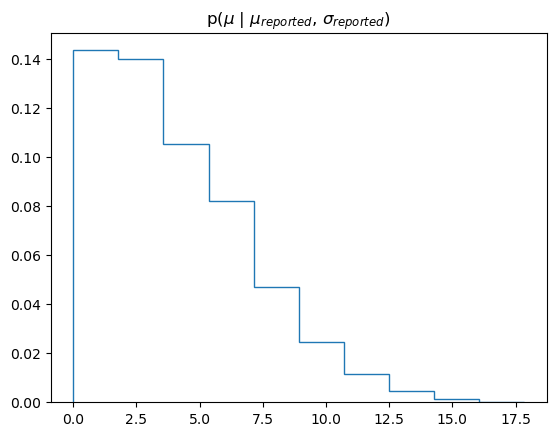

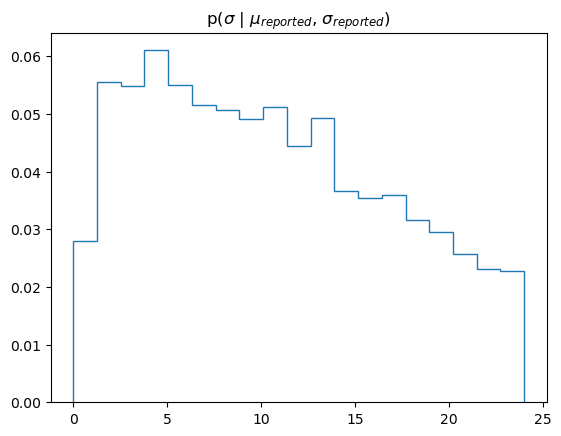

In [9]:
plt.hist(df['mu_true'], histtype='step', density=1)
plt.title(r'p($\mu$ | $\mu_{reported}$, $\sigma_{reported}$)')
plt.show()

plt.hist(df['sigma_true'], histtype='step', bins=np.linspace(0,3*my_data['sigma_rep'],20), density=1)
plt.title(r'p($\sigma$ | $\mu_{reported}$, $\sigma_{reported}$)')
plt.show()

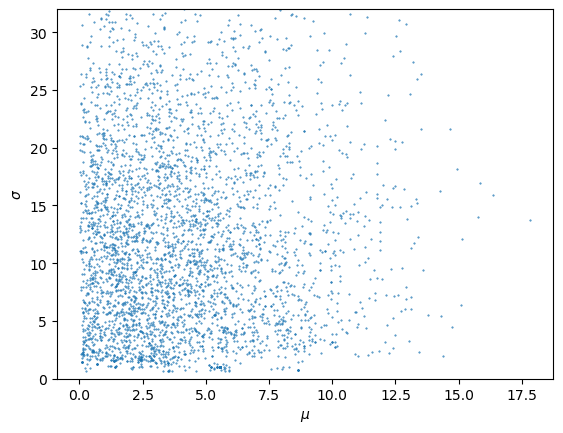

In [10]:
plt.scatter(df['mu_true'], df['sigma_true'], s=0.2)
plt.ylim(0,4*my_data['sigma_rep'])
plt.xlabel('$\mu$')
plt.ylabel('$\sigma$')
plt.show()